# Reverse Correlation Annotation Analysis

In [1]:
import os
import glob
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
proj_dir = '/Users/hpopal/Google Drive/My Drive/dscn_lab/projects/net/'
data_dir = proj_dir+'derivatives/reverse_correlation/group_results/'
outp_dir = proj_dir+'derivatives/reverse_correlation/annotation_analysis'

os.chdir(proj_dir)

In [3]:
roi_data_files = glob.glob(data_dir+'*_ts_stats.csv')
roi_data_files.sort()

group_roi_ts_stats = {}

for temp_file in roi_data_files:
    temp_label = temp_file.split('/')[-1].split('_')[0]

    group_roi_ts_stats[temp_label] = pd.read_csv(temp_file, index_col=0).T


cb_roi_names = list(group_roi_ts_stats.keys())

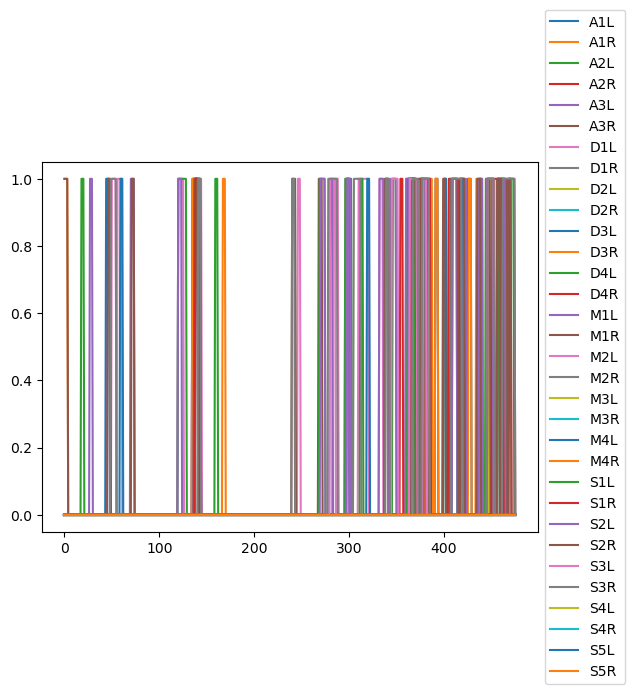

In [6]:
plt.figure()

for temp_label in cb_roi_names:
    group_roi_ts_stats[temp_label]['sig_tw'].plot(label=temp_label)
    
plt.legend(loc='center left', bbox_to_anchor=(1,0.5))

In [7]:
# Calculate mutual agreement between each cerebellum ROI
from sklearn.metrics import mutual_info_score

# Create empty dataframe to serve as matrix
sig_roi_mtx = pd.DataFrame(columns=cb_roi_names, 
                           index=cb_roi_names)

for temp_roi_a in cb_roi_names:
    temp_data_a = group_roi_ts_stats[temp_roi_a]['sig_tw']
    
    for temp_roi_b in cb_roi_names:
        temp_data_b = group_roi_ts_stats[temp_roi_b]['sig_tw']
        
        temp_score = sum(temp_data_a == temp_data_b) / len(temp_data_a)
        
        sig_roi_mtx.loc[temp_roi_a, temp_roi_b] =  temp_score

<Axes: >

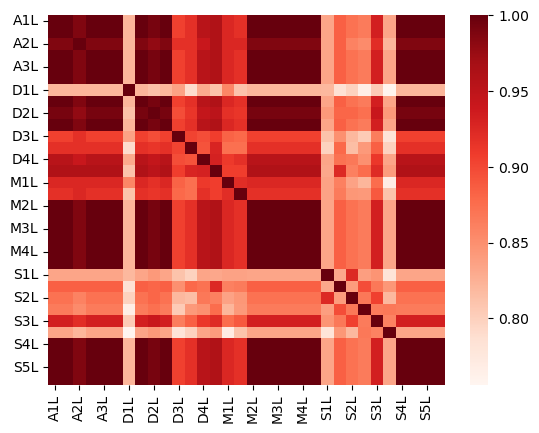

In [8]:
sns.heatmap(sig_roi_mtx.apply(pd.to_numeric), cmap='Reds')

## Annotation Analysis

In [9]:
video_timing = pd.read_csv(proj_dir+'derivatives/task-naturalistic/stimuli/video_timing.csv')
video_timing.head()

,Run,Video,Onset
0,1,grapes_hd,13.750
1,1,wedding_hd,146.149
2,1,awkward_hd,367.617
3,2,ballet_hd,13.750
4,2,penguins_hd,211.556


In [10]:
run = 1

run_video_timing = video_timing[video_timing['Run'] == run]

In [11]:
run_annot_data = {}

for i_vid in range(len(run_video_timing)):
    video_name = run_video_timing.iloc[i_vid]['Video']
    run_annot_data[video_name] = pd.read_csv(proj_dir+'derivatives/speech_analysis/annotations/'+video_name+'_annotations.csv',
                                            index_col=0)



In [24]:
run_annot_data['grapes_hd'].head()

,Text,Start_time,End_time,Text_clean,neg,neu,pos
0,"I remember we were working when my father says,",0.74,4.70,"remember working father say ,",0.0,1.0,0.0
1,"come on, we're leaving.",4.92,6.16,"come , 're leaving .",0.0,1.0,0.0
2,"I says, we're leaving.",7.10,8.00,"say , 're leaving .",0.0,1.0,0.0
3,It's 10 o'clock in the morning.,8.26,9.14,'s 10 o'clock morning .,0.0,1.0,0.0
4,So we left.,9.98,10.86,left .,0.0,1.0,0.0


### Create Regressors

In [13]:
from nilearn.glm.first_level import compute_regressor

In [14]:
tr = 1.25  # repetition time is 1 second
n_scans = 476  # the acquisition comprises 128 scans
frame_times = np.arange(n_scans) * tr 

In [22]:
# Make onsets like file
events = pd.DataFrame(columns=['trial_type', 'onset', 'duration'])

for temp_video in run_annot_data.keys():
    temp_events = pd.DataFrame(columns=['trial_type', 'onset', 'duration'])

    video_onset = run_video_timing[run_video_timing['Video'] == temp_video]['Onset'].iloc[0]
    
    temp_events['trial_type'] = run_annot_data[temp_video]['Text']
    temp_events['onset'] = pd.to_numeric(run_annot_data[temp_video]['Start_time']) + video_onset
    temp_events['duration'] = pd.to_numeric(run_annot_data[temp_video]['End_time'] - run_annot_data[temp_video]['Start_time'])

    events = pd.concat([events, temp_events])
    

# Make empty dataframe for feature regressors
features_df = pd.DataFrame(index = frame_times)

features = ['neg','neu','pos']

for feat in features:
    events[feat] = pd.to_numeric(run_annot_data[temp_video][feat])

    temp_dm = events[['onset','duration',feat]].to_numpy()
    signal_feat, _labels = compute_regressor(temp_dm.T, 'spm', 
                                            frame_times, con_id=feat)

    features_df[feat] = signal_feat

# Reset index to be TRs rather than time in seconds
features_df = features_df.reset_index(drop=True)


/var/folders/85/t_6qbb0j2pvbbd0sq3zrwbc00000gq/T/ipykernel_11815/2897983065.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  events = pd.concat([events, temp_events])


<Axes: >

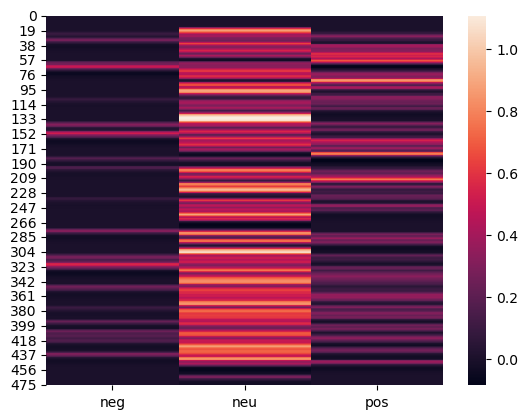

In [23]:
sns.heatmap(features_df)

In [54]:
temp_roi_data_act[temp_roi_data_act['sig_tw'] == 1]

,mean,t,p,p_fdr,sig_tw,pos,neg
138,0.482308,3.325488,0.001535,0.045661,1.0,NaN,NaN
139,0.410634,3.262482,0.001853,0.048662,1.0,NaN,NaN
140,0.435710,3.532046,0.000816,0.043165,1.0,NaN,NaN
400,0.436708,3.567186,0.000732,0.043165,1.0,NaN,NaN
401,0.441599,3.415416,0.001169,0.045661,1.0,NaN,NaN
402,0.456438,3.867550,0.000281,0.036161,1.0,NaN,NaN


In [90]:
roi_annot_summary = pd.DataFrame(columns=['ROI','Activation']+list(features_df.columns))

i_row = 0

for temp_roi in cb_roi_names:
    for temp_act in ['pos', 'neg']:
        for temp_feat in features_df.columns:
            # Add feature data to time series MRI data
            group_roi_ts_stats[temp_roi][temp_feat] = list(pd.to_numeric(features_df[temp_feat]))
            
            temp_roi_data = group_roi_ts_stats[temp_roi]

            if temp_act == 'pos':
                temp_roi_data_act = temp_roi_data[temp_roi_data['mean'] > 0]
            else:
                temp_roi_data_act = temp_roi_data[temp_roi_data['mean'] < 0]
            
            if sum(temp_roi_data_act['sig_tw'] == 1) == 0:
                temp_feat_score = 0
            else:
                temp_feat_sig = temp_roi_data_act[temp_roi_data_act['sig_tw'] == 1][temp_feat]
                temp_feat_score = sum(temp_feat_sig)/len(temp_feat_sig)
                
                
                #roi_annot_summary.loc[temp_roi, temp_feat] = sum(features_df.loc[temp_feat_sig,temp_feat])/len(temp_feat_sig)

            roi_annot_summary.loc[i_row, 'ROI'] = temp_roi
            roi_annot_summary.loc[i_row, 'Activation'] = temp_act
            roi_annot_summary.loc[i_row, temp_feat] = temp_feat_score

        i_row += 1

roi_annot_summary.head()

,ROI,Activation,neg,neu,pos
0,A1L,pos,0,0,0
1,A1L,neg,0,0,0
2,A1R,pos,0,0,0
3,A1R,neg,0,0,0
4,A2L,pos,0.134906,0.340445,0.267004


[Text(0, 0.5, ''),
 Text(0, 2.5, ''),
 Text(0, 4.5, ''),
 Text(0, 6.5, ''),
 Text(0, 8.5, ''),
 Text(0, 10.5, ''),
 Text(0, 12.5, ''),
 Text(0, 14.5, ''),
 Text(0, 16.5, ''),
 Text(0, 18.5, ''),
 Text(0, 20.5, ''),
 Text(0, 22.5, ''),
 Text(0, 24.5, ''),
 Text(0, 26.5, ''),
 Text(0, 28.5, ''),
 Text(0, 30.5, '')]

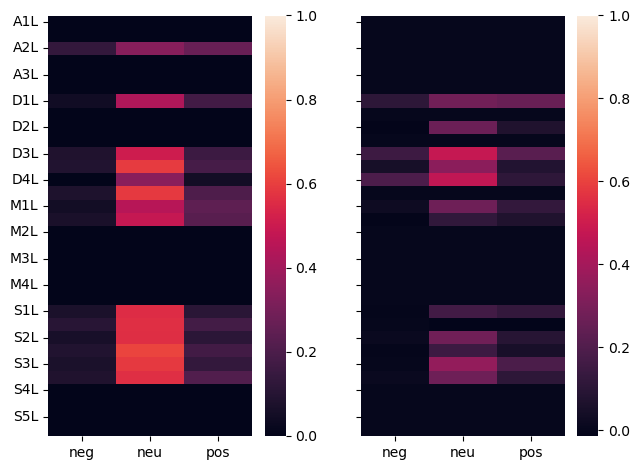

In [102]:
fig, (ax1, ax2) = plt.subplots(1,2)
fig.tight_layout()

roi_annot_summary_pos = roi_annot_summary[roi_annot_summary['Activation'] == 'pos'][['neg','neu','pos']]
roi_annot_summary_neg = roi_annot_summary[roi_annot_summary['Activation'] == 'neg'][['neg','neu','pos']]
roi_annot_summary_pos.index = roi_annot_summary['ROI'].unique()
roi_annot_summary_neg.index = roi_annot_summary['ROI'].unique()

plot1 = sns.heatmap(roi_annot_summary_pos.apply(pd.to_numeric), ax=ax1, vmax=1)
plot2 = sns.heatmap(roi_annot_summary_neg.apply(pd.to_numeric), ax=ax2, vmax=1)
plot2.set_yticklabels('')
